In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(r"C:/Users/Nikhil/OneDrive/Documents/Python projects/Netflix Data Analysis/Dataset/netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [12]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [16]:
df["date_added"].dtype

dtype('<M8[ns]')

In [17]:
df["year_added"] = df["date_added"].dt.year

In [18]:
df["month_added"] = df["date_added"].dt.month_name()

In [19]:
df[["date_added", "year_added", "month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,September
1,2021-09-24,2021.0,September
2,2021-09-24,2021.0,September
3,2021-09-24,2021.0,September
4,2021-09-24,2021.0,September


In [20]:
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)

In [21]:
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

In [22]:
df[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
5,1 Season,1.0,Season
6,91 min,91.0,min
7,125 min,125.0,min
8,9 Seasons,9.0,Seasons
9,104 min,104.0,min


In [23]:
df.isnull().sum()

show_id              0
type                 0
title                0
director          2634
cast               825
country            831
date_added          98
release_year         0
rating               4
duration             3
listed_in            0
description          0
year_added          98
month_added         98
duration_value       3
duration_unit        3
dtype: int64

In [24]:
df.to_csv("netflix_titles_cleaned.csv", index=False)

# Business Question 1

## What is the Distribution of Movies vs TV Shows?

This analysis examines the proportion of Movies and TV Shows available on Netflix. Understanding the content mix helps identify Netflix's primary content strategy and audience focus.

In [25]:
content_type = df["type"].value_counts()

content_type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

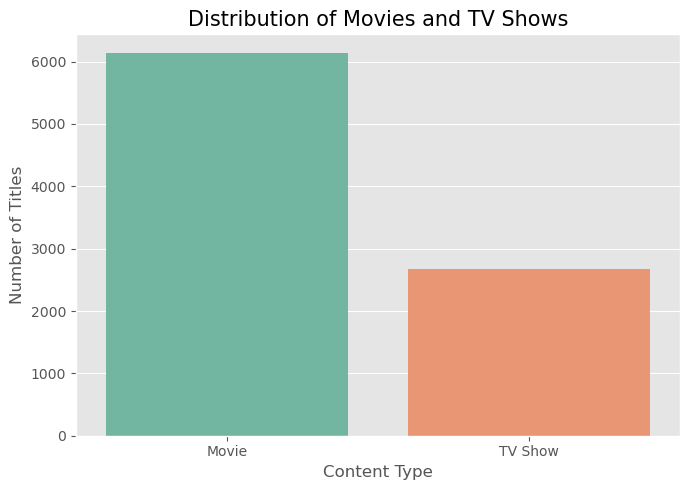

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Movies and TV Shows", fontsize=15)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

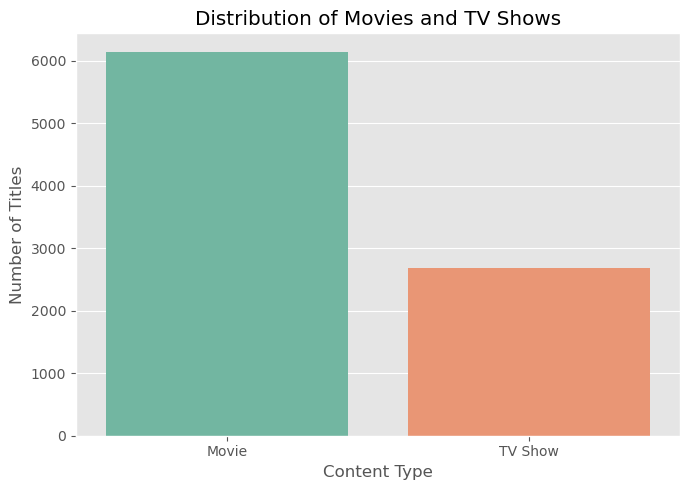

In [27]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig(
    "images/movies_vs_tvshows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

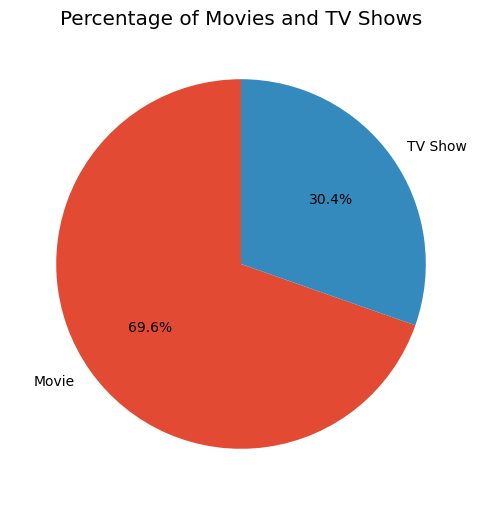

In [28]:
plt.figure(figsize=(6,6))

plt.pie(
    content_type,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Movies and TV Shows")

plt.show()

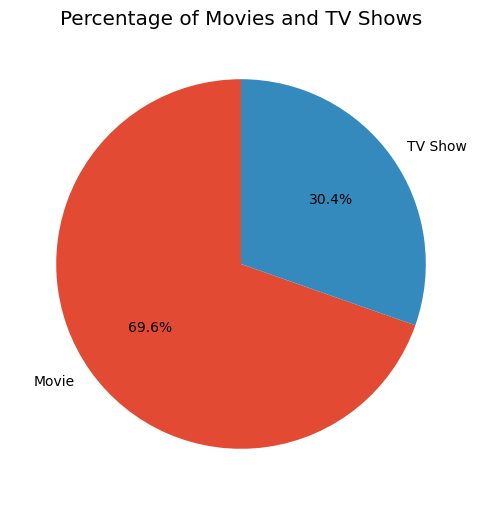

In [29]:
plt.figure(figsize=(6,6))

plt.pie(
    content_type,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Movies and TV Shows")

plt.savefig(
    "images/movies_vs_tvshows_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 2

## Which Countries Produce the Most Netflix Content?

This analysis identifies the countries that contribute the highest number of titles to Netflix. Understanding content production by country helps reveal Netflix's major content markets and regional content distribution.

In [30]:
country_df = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

country_df.head()

0    United States
1     South Africa
4            India
7    United States
7            Ghana
Name: country, dtype: object

Find the Top 10 Countries

In [31]:
top_countries = country_df.value_counts().head(10)

top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

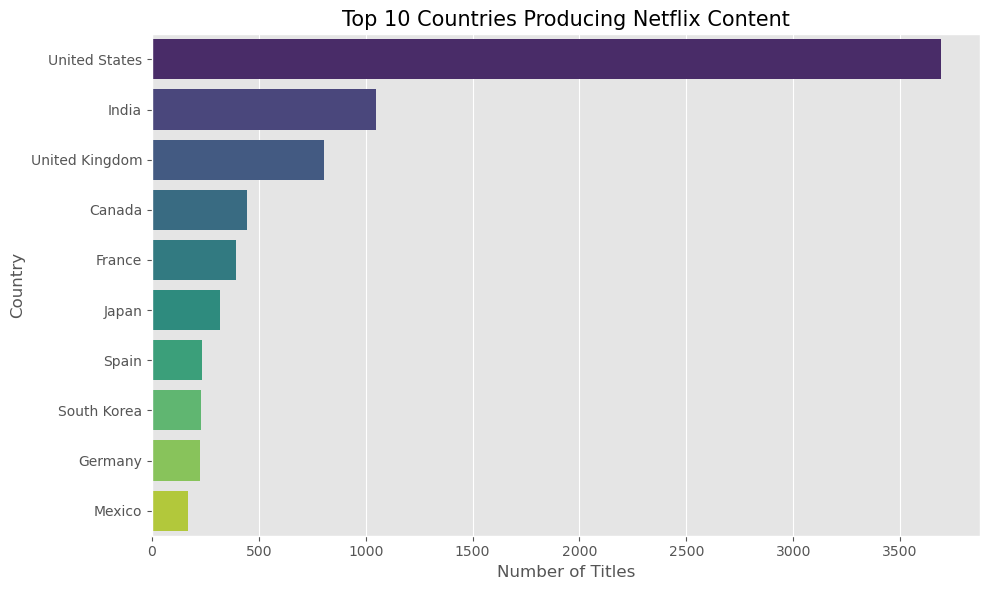

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries Producing Netflix Content", fontsize=15)
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

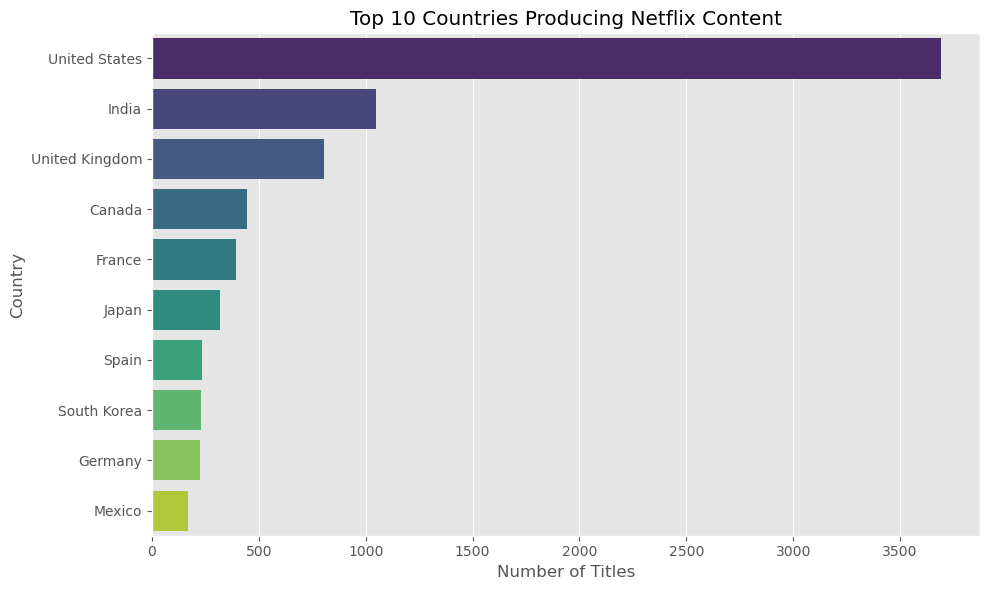

In [33]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "images/top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 3

## Which Genres Are Most Popular on Netflix?

This analysis identifies the most common genres available on Netflix. Understanding genre distribution helps reveal audience preferences and Netflix's content strategy across different categories.

In [34]:
genre_df = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

Find the Top 10 Genres

In [35]:
top_genres = genre_df.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

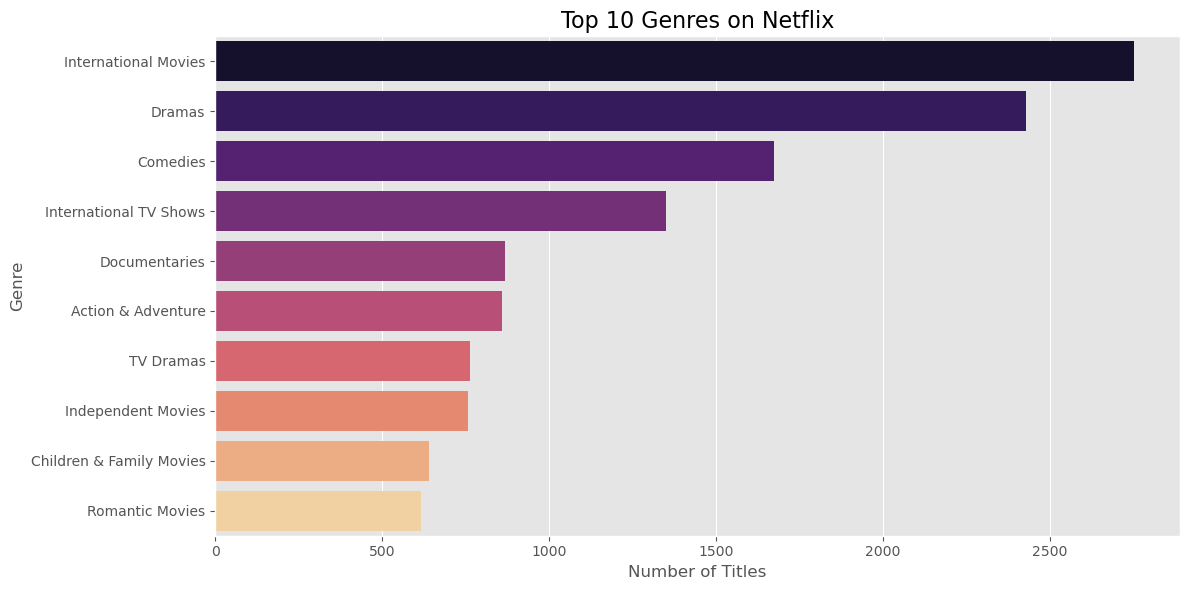

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Genres on Netflix", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

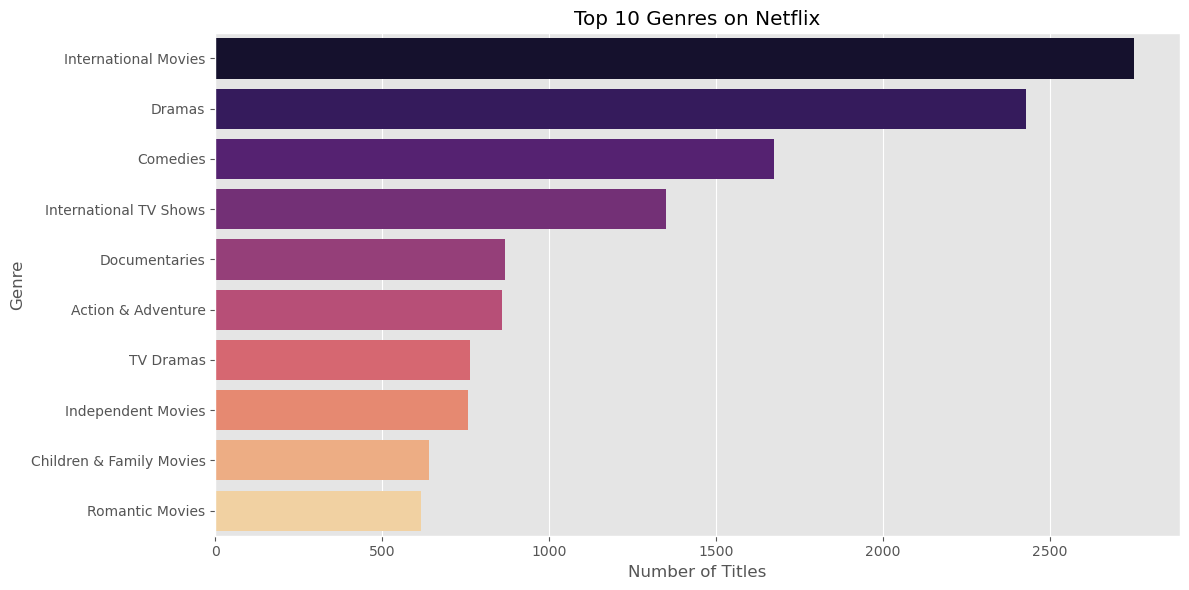

In [37]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig(
    "images/top_10_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 4

## Which Directors Have the Most Titles on Netflix?

This analysis identifies the directors with the highest number of titles available on Netflix. Understanding director contributions helps highlight key content creators and supports strategic decisions for future collaborations.

In [39]:
director_df = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
)

director_df.head()

0    Kirsten Johnson
2    Julien Leclercq
5      Mike Flanagan
6      Robert Cullen
6     José Luis Ucha
Name: director, dtype: object

Find the Top 10 Directors

In [40]:
top_directors = director_df.value_counts().head(10)

top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64

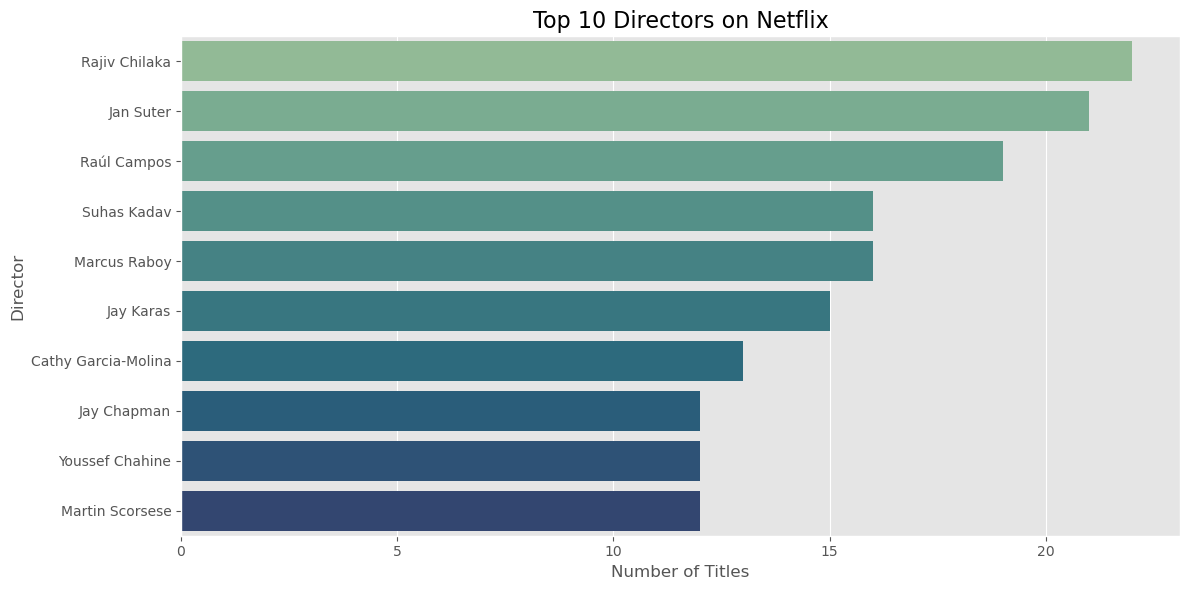

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Directors on Netflix", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.tight_layout()
plt.show()

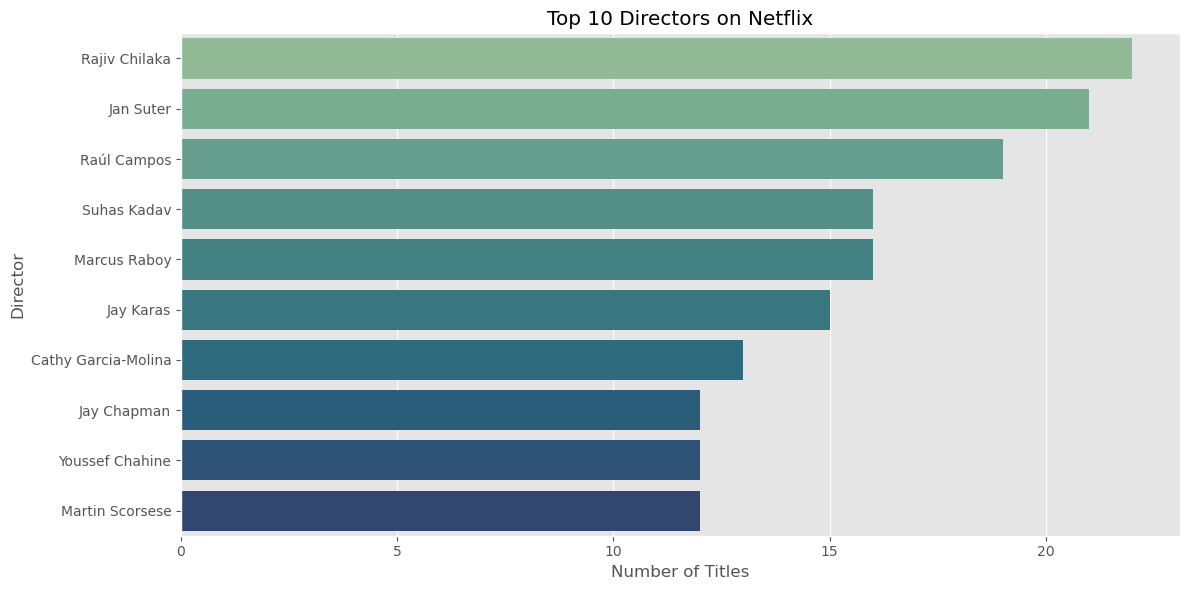

In [42]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.tight_layout()

plt.savefig(
    "images/top_10_directors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 5

## Which Years Had the Highest Number of Content Releases?

This analysis examines the number of Movies and TV Shows released each year. Understanding release trends helps identify changes in content production and provides insights into Netflix's content library over time.

In [43]:
release_year = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

release_year.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

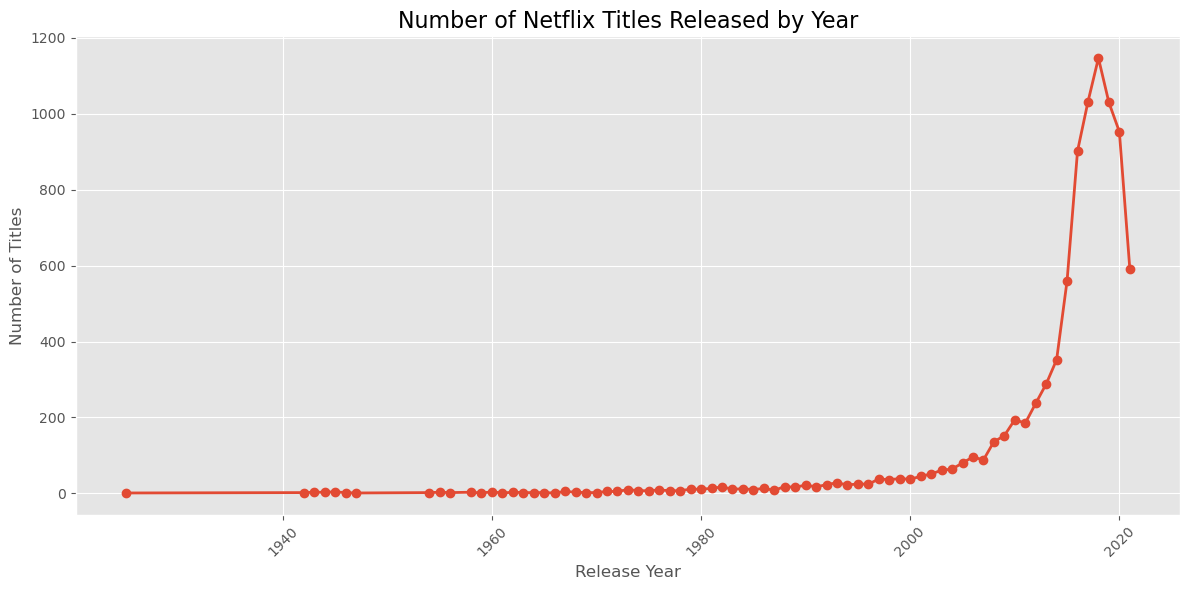

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    release_year.index,
    release_year.values,
    marker="o",
    linewidth=2
)

plt.title("Number of Netflix Titles Released by Year", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

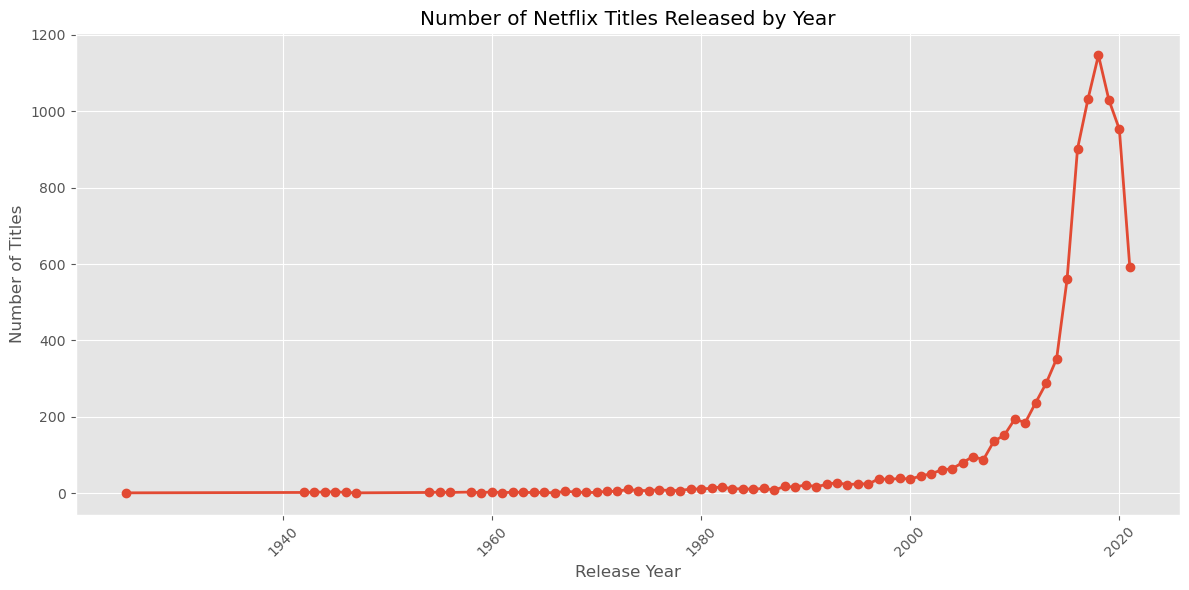

In [45]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

plt.plot(
    release_year.index,
    release_year.values,
    marker="o",
    linewidth=2
)

plt.title("Number of Netflix Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/content_released_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Display the Top 10 Years

In [46]:
top_release_years = (
    df["release_year"]
    .value_counts()
    .head(10)
)

top_release_years

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

# Business Question 6

## Which Content Ratings Are Most Common on Netflix?

This analysis examines the distribution of content ratings available on Netflix. Understanding content ratings helps identify the primary audience targeted by Netflix and supports content planning decisions.

In [47]:
rating_counts = (
    df["rating"]
    .value_counts()
)

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

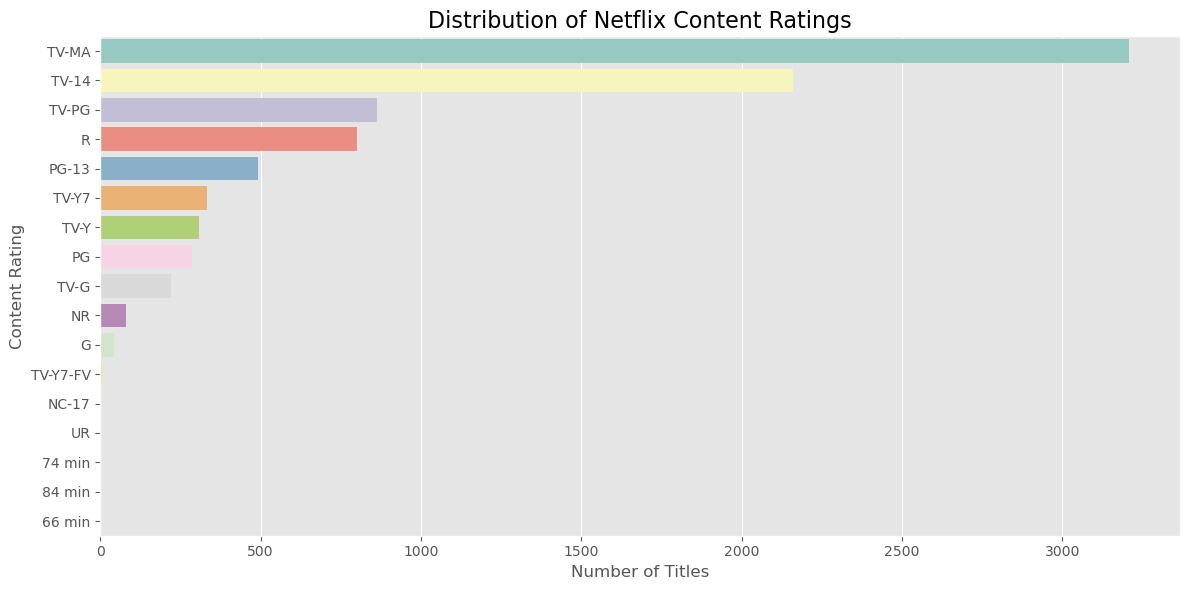

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette="Set3",
    legend=False
)

plt.title("Distribution of Netflix Content Ratings", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Content Rating")

plt.tight_layout()
plt.show()

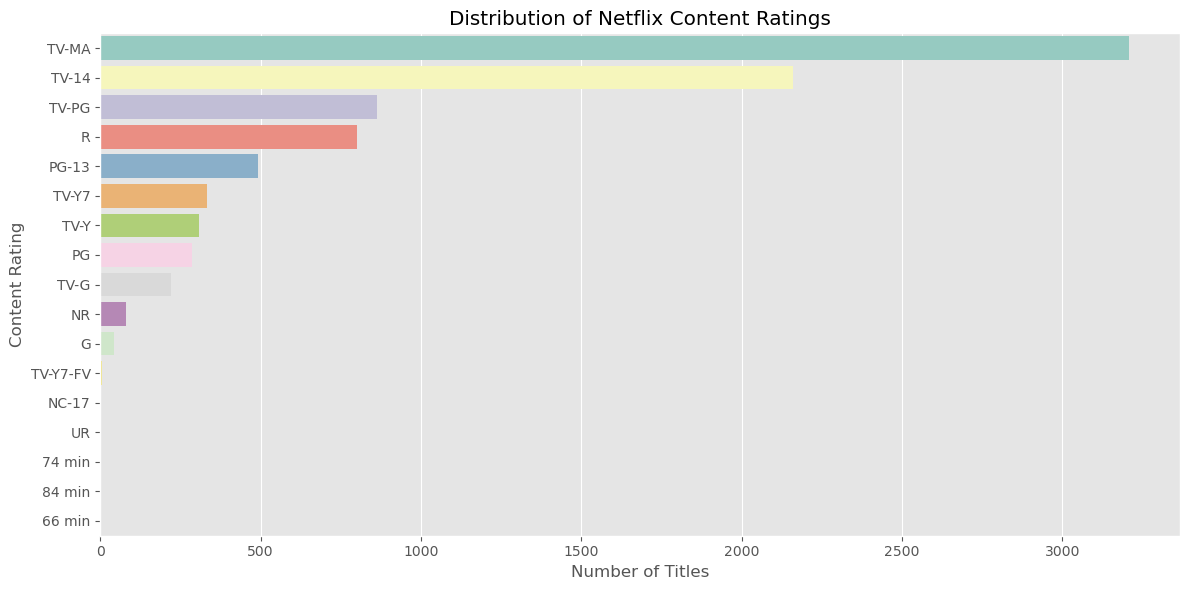

In [49]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette="Set3",
    legend=False
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Content Rating")

plt.tight_layout()

plt.savefig(
    "images/content_ratings_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 7

## What is the Distribution of Movie Durations?

This analysis examines the distribution of movie durations available on Netflix. Understanding movie length helps identify typical content duration and supports content planning based on viewer preferences.

In [50]:
movies = df[df["type"] == "Movie"].copy()

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,90.0,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,September,91.0,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,September,125.0,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,September,104.0,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,September,127.0,min


In [51]:
movies[["title", "duration", "duration_value"]].head()

,title,duration,duration_value
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0


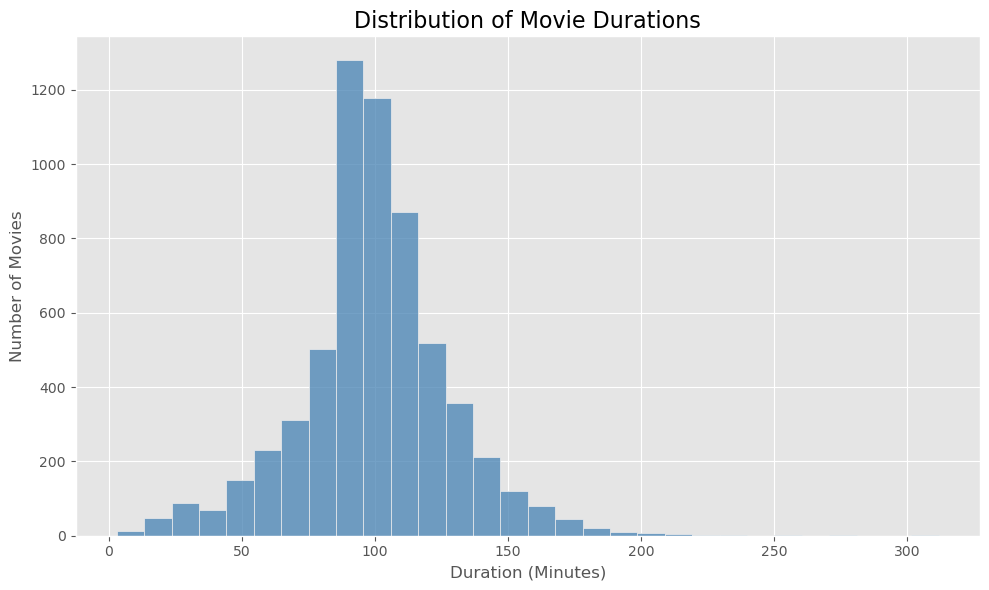

In [52]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=movies,
    x="duration_value",
    bins=30,
    color="steelblue"
)

plt.title("Distribution of Movie Durations", fontsize=16)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

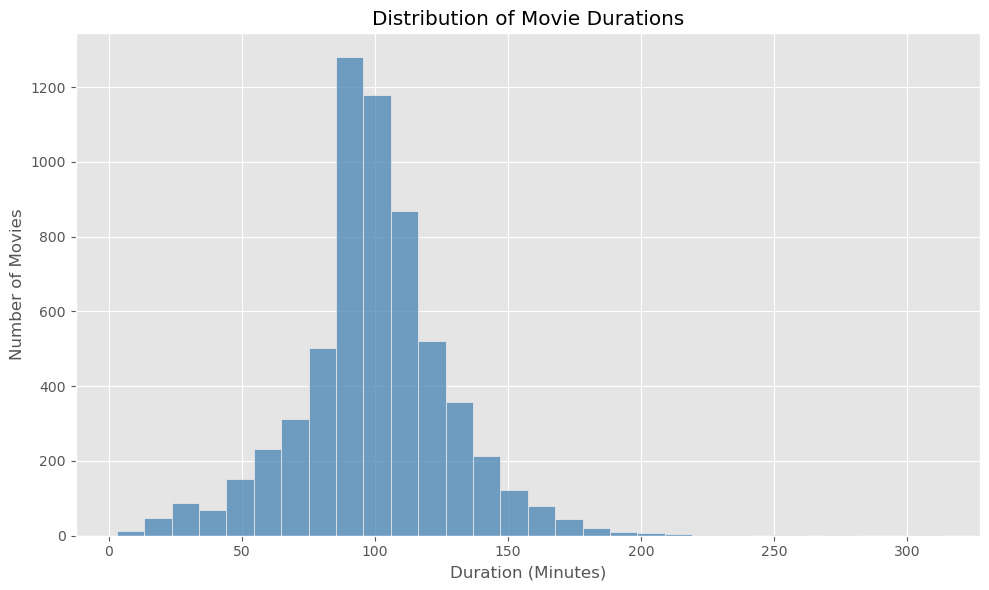

In [53]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,6))

sns.histplot(
    data=movies,
    x="duration_value",
    bins=30,
    color="steelblue"
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig(
    "images/movie_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Calculate Summary Statistics

In [54]:
movies["duration_value"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

# Business Question 8

## How Has Netflix's Content Library Grown Over Time?

This analysis examines the number of Movies and TV Shows added to Netflix each year. It helps understand the platform's content acquisition strategy and overall growth over time.

In [55]:
titles_added = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

titles_added

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

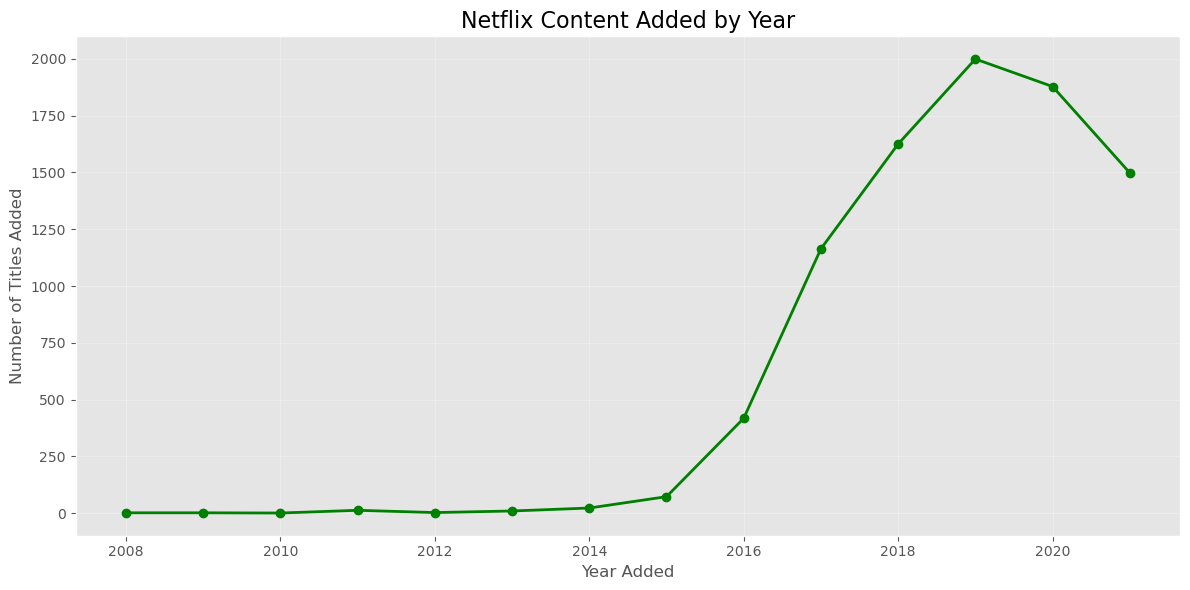

In [56]:
plt.figure(figsize=(12,6))

plt.plot(
    titles_added.index,
    titles_added.values,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Netflix Content Added by Year", fontsize=16)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

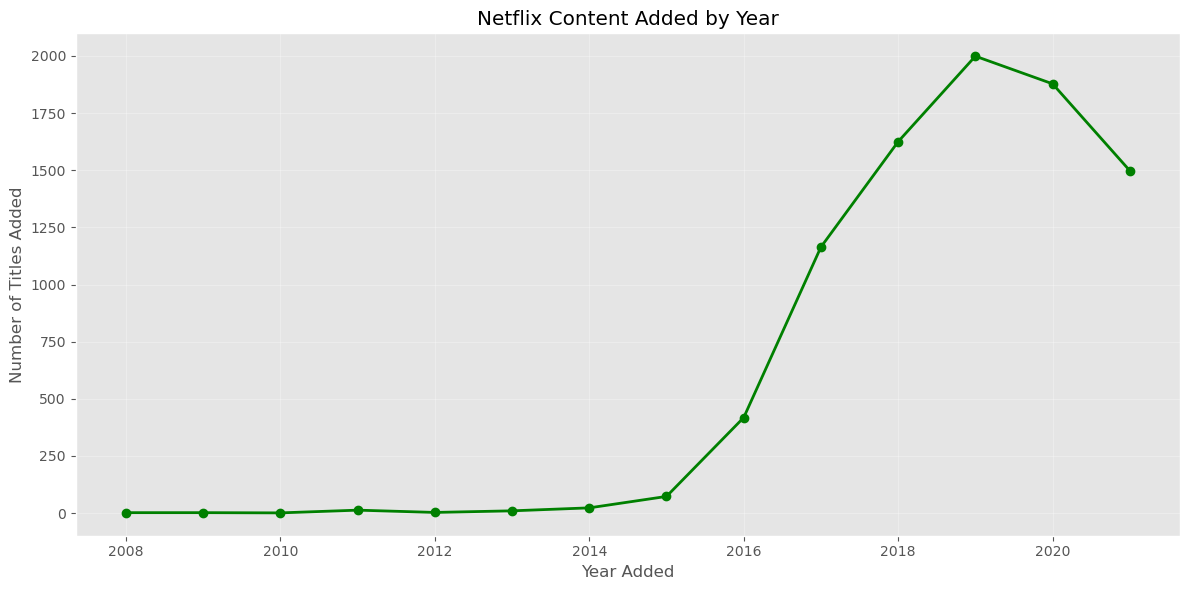

In [57]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

plt.plot(
    titles_added.index,
    titles_added.values,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/content_added_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Show Top 10 Years

In [58]:
titles_added.sort_values(ascending=False).head(10)

year_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
Name: count, dtype: int64

# Business Question 9

## Which Month Has the Highest Number of Content Additions?

This analysis examines the number of titles added to Netflix during each month of the year. Understanding monthly trends helps identify seasonal content release patterns and supports strategic planning for content acquisition.

In [59]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_titles = (
    df["month_added"]
    .value_counts()
    .reindex(month_order)
)

monthly_titles

month_added
January      727
February     557
March        734
April        759
May          626
June         724
July         819
August       749
September    765
October      755
November     697
December     797
Name: count, dtype: int64

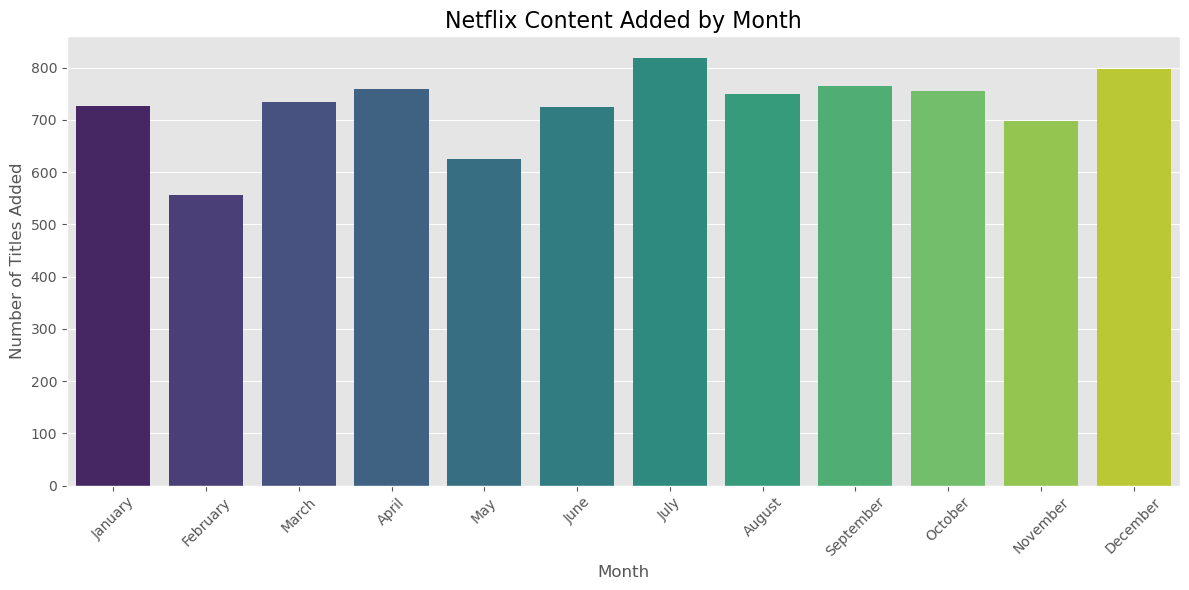

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_titles.index,
    y=monthly_titles.values,
    hue=monthly_titles.index,
    palette="viridis",
    legend=False
)

plt.title("Netflix Content Added by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

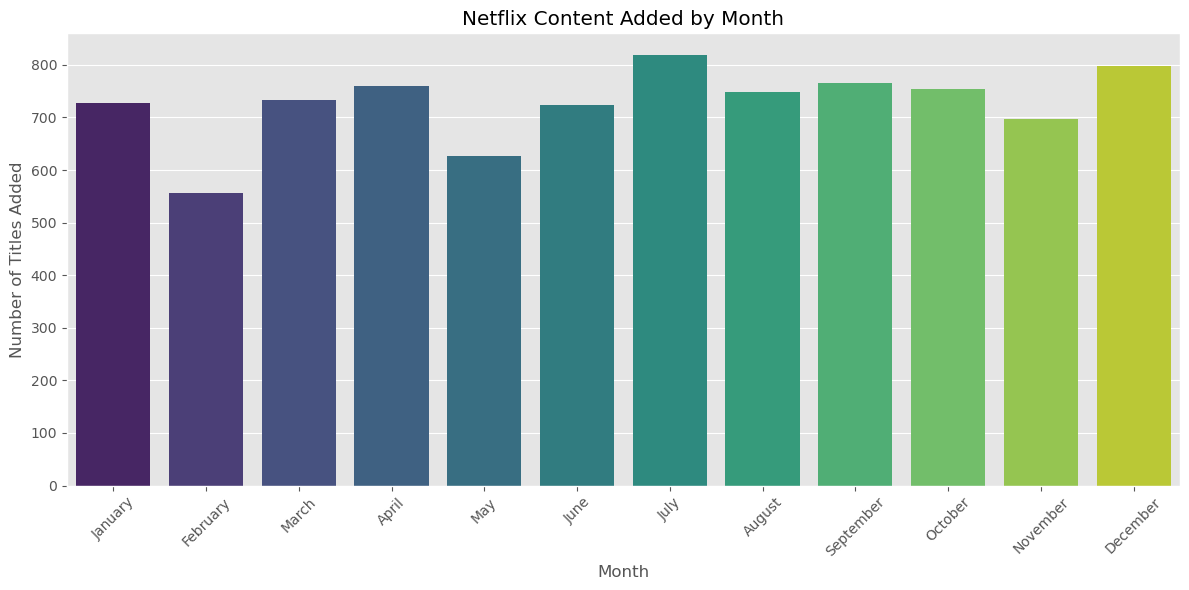

In [61]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_titles.index,
    y=monthly_titles.values,
    hue=monthly_titles.index,
    palette="viridis",
    legend=False
)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/content_added_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 10

## How Has Netflix Added Movies and TV Shows Over the Years?

This analysis compares the number of Movies and TV Shows added to Netflix each year. It helps identify changes in Netflix's content acquisition strategy and whether the platform has shifted its focus between Movies and TV Shows.

In [62]:
content_trend = (
    df.groupby(["year_added", "type"])
      .size()
      .unstack(fill_value=0)
)

content_trend.head()

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0


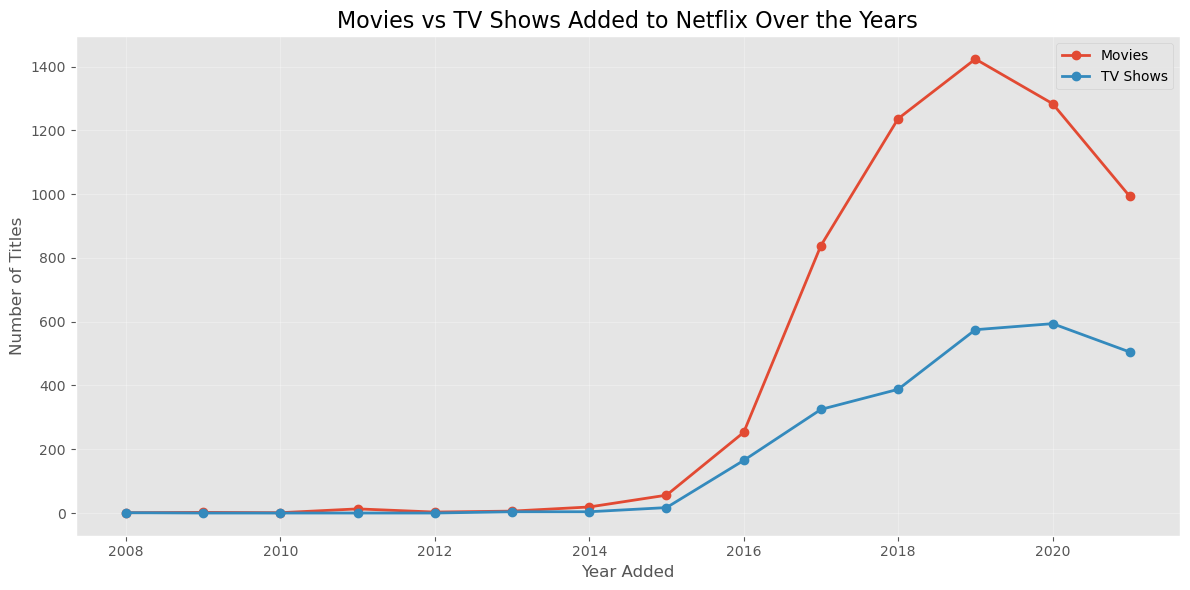

In [63]:
plt.figure(figsize=(12,6))

plt.plot(
    content_trend.index,
    content_trend["Movie"],
    marker="o",
    linewidth=2,
    label="Movies"
)

plt.plot(
    content_trend.index,
    content_trend["TV Show"],
    marker="o",
    linewidth=2,
    label="TV Shows"
)

plt.title("Movies vs TV Shows Added to Netflix Over the Years", fontsize=16)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

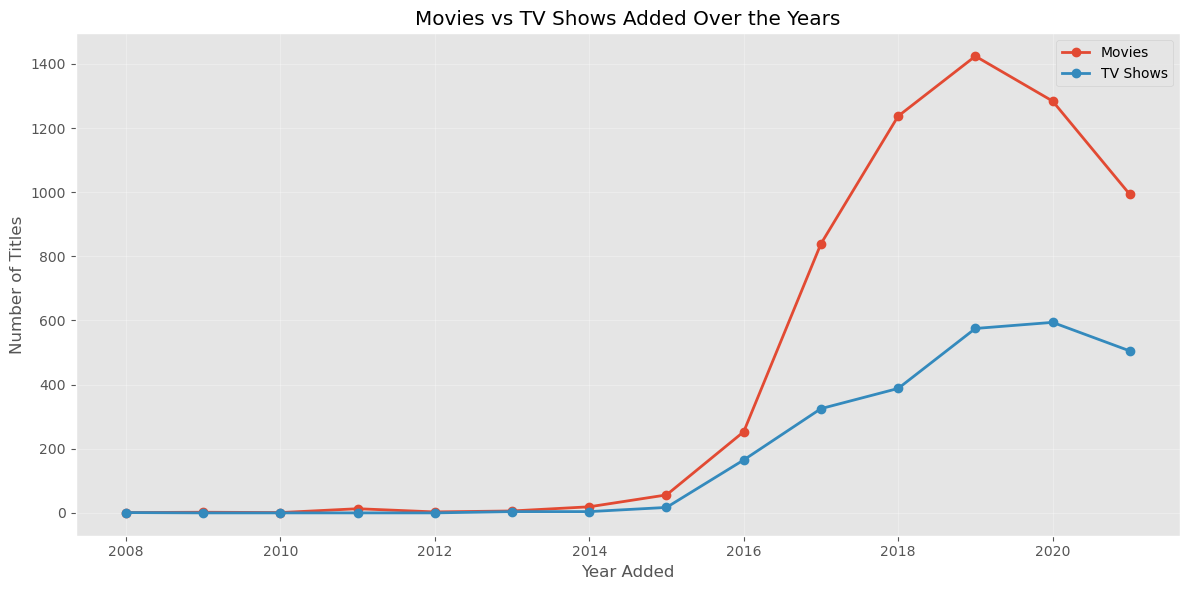

In [64]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12,6))

plt.plot(
    content_trend.index,
    content_trend["Movie"],
    marker="o",
    linewidth=2,
    label="Movies"
)

plt.plot(
    content_trend.index,
    content_trend["TV Show"],
    marker="o",
    linewidth=2,
    label="TV Shows"
)

plt.title("Movies vs TV Shows Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/movies_vs_tvshows_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()